# NQ Futures — ORB Strategy Backtest
**Strategy:** Opening Range Breakout + EMA-20 Trend Filter  
**Timeframe:** 5-minute bars | **Instrument:** NQ=F (E-mini Nasdaq-100)  
**Account:** $50,000 initial equity | **Risk:** < 5% per trade | **SL:** 2% | **TP:** 4%

In [1]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

# Make sure the project root is on the path
sys.path.insert(0, os.getcwd())

from data_fetch import fetch_data
from strategy  import run_backtest, INITIAL_EQUITY

## 1. Load Data

In [2]:
# Set refresh=True to force a fresh download from Yahoo Finance
df = fetch_data(refresh=False)

print(f"Bars loaded : {len(df):,}")
print(f"Date range  : {df.index[0].strftime('%Y-%m-%d')} -> {df.index[-1].strftime('%Y-%m-%d')}")
df.tail(3)

[data_fetch] Loading cached data from data\NQ_5m.csv ...
[data_fetch] Loaded 3,700 rows (2026-01-05 -> 2026-03-16)
Bars loaded : 3,700
Date range  : 2026-01-05 -> 2026-03-16


,close,high,low,open,volume
datetime,,,,,
2026-03-16 15:45:00-04:00,24871.75,24879.50,24859.75,24872.75,3121
2026-03-16 15:50:00-04:00,24867.00,24886.00,24850.00,24871.00,4769
2026-03-16 15:55:00-04:00,24884.75,24896.25,24866.75,24866.75,9704


## 2. Run Backtest

In [3]:
trades, equity = run_backtest(df)
print(f"Total trades : {len(trades)}")
print(f"Trading days : {trades['date'].nunique()}")
trades.head()

Total trades : 47
Trading days : 47


,date,direction,entry_time,exit_time,exit_reason,entry_price,exit_price,contracts,pnl,equity_after
0,2026-01-05,LONG,2026-01-05 10:30:00-05:00,2026-01-05 15:45:00-05:00,EOD,25674.25,25607.50,2,-267.0,49733.0
1,2026-01-06,LONG,2026-01-06 10:25:00-05:00,2026-01-06 15:45:00-05:00,EOD,25763.25,25826.25,2,252.0,49985.0
2,2026-01-07,LONG,2026-01-07 10:35:00-05:00,2026-01-07 15:45:00-05:00,EOD,25882.00,25834.75,2,-189.0,49796.0
3,2026-01-09,SHORT,2026-01-09 10:10:00-05:00,2026-01-09 15:45:00-05:00,EOD,25642.25,25961.25,2,-1276.0,48520.0
4,2026-01-12,LONG,2026-01-12 11:10:00-05:00,2026-01-12 15:45:00-05:00,EOD,25925.50,25984.25,2,235.0,48755.0


## 3. Performance Metrics

In [4]:
# ── Compute metrics ────────────────────────────────────────────────────────
total    = len(trades)
wins     = (trades['pnl'] > 0).sum()
losses   = (trades['pnl'] < 0).sum()
win_rate = wins / total * 100

days_traded     = trades['date'].nunique()
trades_per_year = (total / max(days_traded, 1)) * 252
mean_pnl        = trades['pnl'].mean()
std_pnl         = trades['pnl'].std(ddof=1)
sharpe          = (mean_pnl / std_pnl) * math.sqrt(trades_per_year) if std_pnl else float('nan')

running_peak    = equity.cummax()
drawdown_series = (equity - running_peak) / running_peak * 100
max_drawdown    = abs(drawdown_series.min())

final_equity  = equity.iloc[-1]
total_return  = (final_equity - INITIAL_EQUITY) / INITIAL_EQUITY * 100
net_pnl       = trades['pnl'].sum()
profit_factor = (trades.loc[trades['pnl'] > 0, 'pnl'].sum() /
                 abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum()))
avg_win  = trades.loc[trades['pnl'] > 0, 'pnl'].mean()
avg_loss = trades.loc[trades['pnl'] < 0, 'pnl'].mean()

# ── Display as a styled DataFrame ─────────────────────────────────────────
metrics = pd.DataFrame({
    'Metric': [
        'Total Trades', 'Winning Trades', 'Losing Trades',
        'Win Rate', 'Sharpe Ratio', 'Profit Factor',
        'Net P&L', 'Total Return', 'Final Equity', 'Max Drawdown',
        'Avg Winning Trade', 'Avg Losing Trade',
    ],
    'Value': [
        f"{total}",
        f"{wins}",
        f"{losses}",
        f"{win_rate:.1f}%  {'OK' if win_rate >= 50 else 'BELOW TARGET'}",
        f"{sharpe:.2f}  {'OK' if sharpe >= 1.0 else 'BELOW TARGET'}",
        f"{profit_factor:.2f}",
        f"${net_pnl:+,.2f}",
        f"{total_return:+.1f}%",
        f"${final_equity:,.2f}",
        f"{max_drawdown:.1f}%",
        f"${avg_win:+,.2f}",
        f"${avg_loss:+,.2f}",
    ]
}).set_index('Metric')

metrics

,Value
Metric,
Total Trades,47
Winning Trades,27
Losing Trades,20
Win Rate,57.4% OK
Sharpe Ratio,1.60 OK
Profit Factor,1.31
Net P&L,"$+2,962.00"
Total Return,+5.9%
Final Equity,"$52,962.00"


## 4. Equity Curve

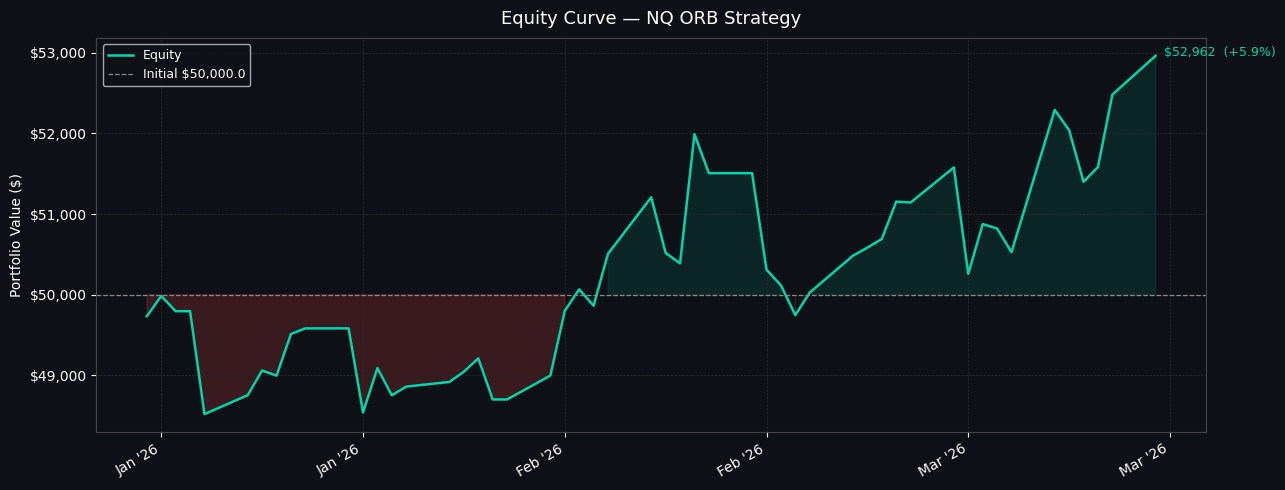

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(equity.index, equity.values, color='#00d4aa', linewidth=1.8, label='Equity')
ax.axhline(INITIAL_EQUITY, color='#888', linewidth=0.9, linestyle='--', label=f'Initial ${INITIAL_EQUITY:,}')

ax.fill_between(equity.index, INITIAL_EQUITY, equity.values,
                where=(equity.values >= INITIAL_EQUITY),
                color='#00d4aa', alpha=0.10)
ax.fill_between(equity.index, INITIAL_EQUITY, equity.values,
                where=(equity.values < INITIAL_EQUITY),
                color='#ff4444', alpha=0.18)

# Annotate final equity
ax.annotate(
    f"  ${final_equity:,.0f}  ({total_return:+.1f}%)",
    xy=(equity.index[-1], equity.iloc[-1]),
    fontsize=9, color='#00d4aa',
)

ax.set_title('Equity Curve — NQ ORB Strategy', fontsize=13, pad=10)
ax.set_ylabel('Portfolio Value ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Drawdown

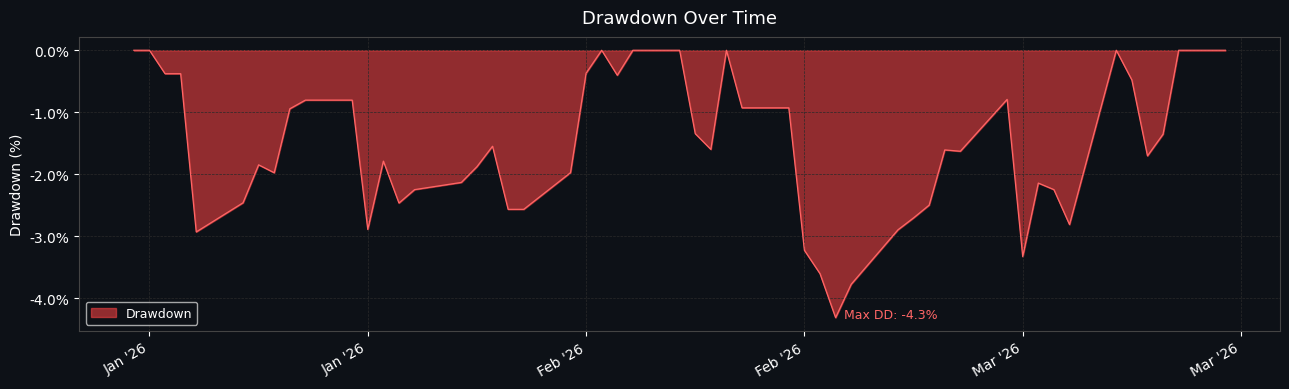

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(equity.index, drawdown_series.values, 0,
                color='#ff4444', alpha=0.55, label='Drawdown')
ax.plot(equity.index, drawdown_series.values, color='#ff6666', linewidth=0.9)

# Annotate worst drawdown
worst_idx = drawdown_series.idxmin()
ax.annotate(
    f"  Max DD: -{max_drawdown:.1f}%",
    xy=(worst_idx, drawdown_series[worst_idx]),
    fontsize=9, color='#ff6666',
)

ax.set_title('Drawdown Over Time', fontsize=13, pad=10)
ax.set_ylabel('Drawdown (%)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Trade Log

In [7]:
trades.style.applymap(
    lambda v: 'color: #00d4aa' if isinstance(v, (int, float)) and v > 0
              else ('color: #ff4444' if isinstance(v, (int, float)) and v < 0 else ''),
    subset=['pnl']
)

C:\Users\kunpa\AppData\Local\Temp\ipykernel_8532\156321837.py:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  trades.style.applymap(


,date,direction,entry_time,exit_time,exit_reason,entry_price,exit_price,contracts,pnl,equity_after
0,2026-01-05,LONG,2026-01-05 10:30:00-05:00,2026-01-05 15:45:00-05:00,EOD,25674.250000,25607.500000,2,-267.000000,49733.000000
1,2026-01-06,LONG,2026-01-06 10:25:00-05:00,2026-01-06 15:45:00-05:00,EOD,25763.250000,25826.250000,2,252.000000,49985.000000
2,2026-01-07,LONG,2026-01-07 10:35:00-05:00,2026-01-07 15:45:00-05:00,EOD,25882.000000,25834.750000,2,-189.000000,49796.000000
3,2026-01-09,SHORT,2026-01-09 10:10:00-05:00,2026-01-09 15:45:00-05:00,EOD,25642.250000,25961.250000,2,-1276.000000,48520.000000
4,2026-01-12,LONG,2026-01-12 11:10:00-05:00,2026-01-12 15:45:00-05:00,EOD,25925.500000,25984.250000,2,235.000000,48755.000000
5,2026-01-13,SHORT,2026-01-13 10:05:00-05:00,2026-01-13 15:45:00-05:00,EOD,25930.500000,25854.000000,2,306.000000,49061.000000
6,2026-01-14,SHORT,2026-01-14 10:05:00-05:00,2026-01-14 15:45:00-05:00,EOD,25556.250000,25572.250000,2,-64.000000,48997.000000
7,2026-01-15,SHORT,2026-01-15 10:50:00-05:00,2026-01-15 15:45:00-05:00,EOD,25823.500000,25694.500000,2,516.000000,49513.000000
8,2026-01-16,SHORT,2026-01-16 10:15:00-05:00,2026-01-16 15:45:00-05:00,EOD,25720.500000,25703.000000,2,70.000000,49583.000000
9,2026-01-20,LONG,2026-01-20 10:35:00-05:00,2026-01-20 15:45:00-05:00,EOD,25385.500000,25124.750000,2,-1043.000000,48540.000000
